# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [1]:
import random
class Card():           #Card Class
    def __init__(self, suit, value):
        self.value= value          #Value of respective card
        self.suit= suit            # Suit of respective card


    def __repr__(self):     # Print the card in readbale format: 2 of Heart for example
        return f"{self.value} of {self.suit}"

class Deck:
    def __init__(self, n_decks=6):      #Takes 6 decks by default if not mentioned by users.
        self.n_decks= n_decks
        self.values= list(range(2, 11))+["J", "Q", "K", "A"]        #Different Values within a deck
        self.suits= list(['Spade', 'Club', 'Diamond', 'Heart'])     #Different suits in a deck
        self.get_deck()                 #Declaring 'deck' method
        self.shuffle()              #Declaring 'shuffle' method
    
    def get_deck(self):
        self.cards=[]
        for i in range(self.n_decks):   #Loop for number of decks
            for suit in self.suits:     #Loops suits and values (Nested), and adds every 'Card' in a deck to a list
                for value in self.values:
                    self.cards.append(Card(suit, value))        
        self.cards.insert(random.randint(0, len(self.cards)), 'plastic')        #Randomly places a 'plastic' card in the deck

    def shuffle(self):          #Shuffles the deck
        random.shuffle(self.cards)
    
    def draw(self):             #Draws the top most card from the deck
        card= self.cards.pop()  #removes and returns the item at nth index: last index, by default

        if card=="plastic":     #If drawn card is 'plastic', create a new deck, shuffle, and again draw.
            print("Plastic card hass been draw. The Deck will be reshuffled!")
            self.get_deck()
            self.shuffle()
            return self.draw()
        return card     #Returns if drawn card is not plastic
    
    def __repr__(self):
        return f"{self.n_decks} Decks of {len(self.cards)} cards and a plastic card at random position."

`NOTE`: The `get_deck` method created the deck, but doesn't return it for maintaining the integrity. Similarly, `shuffle` method shuffles the deck, but doesn't return the shuffled deck.

In [2]:
# Testing the Classes:

# Creating an objet
my_deck= Deck(n_decks=2)
print(my_deck)

my_deck.get_deck()  # Initializing deck

# Location of the plastic card: For random placement
shuffled_deck= my_deck.cards
for idx, card in enumerate(shuffled_deck):      #looks for a 'plastic' element in the list of cards and prints its position in the deck
    if card=='plastic':
        print(f"\n Plastic card appear after {idx} cards.")


my_deck.shuffle()   #Shuffling the deck

#Print out 5 cards from the top of a deck:
print("\nFirst five cards of the deck: ")
for i in range(5):
    print(my_deck.draw())

#Cards remaining:
print(f"\nCards remaining in deck: {len(my_deck.cards)}")

2 Decks of 105 cards and a plastic card at random position.

 Plastic card appear after 103 cards.

First five cards of the deck: 
3 of Diamond
J of Spade
9 of Club
3 of Spade
J of Heart

Cards remaining in deck: 100


2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

`NOTE:` The UML Diagram has been saved as a pdf named `UML_Diagram` so please open it with notebook or adobe, and AI and `reportlab` library was used for diong that.

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

I will start with creating various classes, and implementing the respective methods and attributes within each class. Additionally, I will lay over a basic hierarchy of how the actaul game looks like with the inheritance feature of OOP. For instance, a Hand will have several methods and values within it. The hand belongs to players, dealers, or bots in the game.

In [3]:
class Hand():  #Defining a hand
    #Initializes a new object instance this class
    def __init__(self):
        self.card_in_hand=[]    #Cards in player, dealer, or bot's hand
        self.bet=0    #For betting of chips later on
    
    
    # For adding a card to the Hand:
    def add_card(self, card):
        pass
    
    
    # For calculating total hand value at any instance
    def claculate_value(self):
        pass
    
    
    #For checking if the current hand is a blackjack: 2 cards with total hand value of 21
    def is_balckjack(self):
        pass
    
    
    #For checking if the hand is bust
    def is_bust(self):
        pass
    
    
    #For printing all the cards in hand in a proper readable format
    def __repr__(self):
        pass

In [4]:
#Defining a Player class
class Player:
    # Initializes an object instance of the class
    def __init__(self, name, chips=1000):    #Takes name of player and their respective chips (by default 1000) as argument
        self.name = name
        self.chips= chips
        self.hand= Hand()    #Hand is a feature of a player so we create its object within the Player class
    
    
    #For placing a bet
    def place_bet(self):
        pass
    
    
    #For player to decide if they want to hit/stay
    def decide(self):
        pass
    
    
    #For when the player wins the game
    def win(self):
        pass
    
    
    #For when its a tie between player and dealer
    def push(self):
        pass

Now, I will be creating a `Dealer` and a `Computer` class inheriting the `Player` class we just created. I did this because dealer and computer bots will have a similar feature in the game except the strategy they use in the `decide()` method. So, I will make these classes inherit the Player class and modify the `decide()` method as per need.

In [5]:
# A Dealer class that inherits the Player class
class Dealer(Player):
    def __init__(self):
        super().__init__("Dealer")   #Initializes all the methods and instances of the Player class
    
    
    #For modifications of the method
    def decide(self):
        pass

In [6]:
#A Computer class that inherits the Player class
class Computer(Player):
    def __init__(self, name):   #name argument for supportive defining of more than 1 bot with different names at same time: minimizes confusion.
        super().__init__(name)
    
    
    #Modifying the functions to automate betting for bots
    def place_bet(self):
        pass
    
    
    #Modifying the function for bot decision: Hit or Stand
    def decide(self):
        pass

`NOTE:` The place bet class is modified for the Computer class for automating the bettings of the bots/computers. 

Lastly, I will wrap everything up in a single class named `Balckjack`

In [7]:
class Balckjack:
    def __init(self, players):    #The players arguemnt represents a list of current players in the game.
        self.deck=Deck()    #A Deck Object instance
        self.player= players    #Will be a list of instances of players/computers
        self.Dealer= Dealer()    #A Dealer object instance
    
    
    
    #For dealing initial cards and placing bets:
    def deal_initial(self):
        for player in players:    #Loops over each player
            player.hand= Hand()   # Initializes a hand for each player
            player.place_bet()    # Places a bet for each player
        
        self.dealer.hand= Hand()    #Creating a Hand for dealer
        pass    #For adding the functionality later
    
    
    
    #For the players' turn after dealer deals the card
    def player_turn(self):
        pass
    
    #For dealers' turn after dealing of the cards
    def dealer_turn(self):
        pass
    
    
    #For checking and setteling the bets after each match/round
    def settle_bets(self):
        pass
    
    
    #For playing 1 round of the game
    def play_round(self):
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

Now, using the previous blueprints for each class, we will add the reqyired functionalities to each of them.

In [8]:
class Hand():
    def __init__(self):
        self.card_in_hand= []
        self.bet= 0


    def add_card(self, card):            #Takes card as an argument and adds it in player's current hand.
        self.card_in_hand.append(card)
    
    def calculate_value(self):
        total= 0
        aces=0
        for card in self.card_in_hand:      #loop through all cards in hand
            if isinstance(card.value, int):    #Check if the card value ranges in between 2 to 10. i.e. is a number
                total+=card.value
            elif card.value in ["J", "Q", "K"]:    #If the card is face value, except 'A', add 10
                total+=10
            else: #Initially adds 11 for aces
                total+=11
                aces+=1
        while total>21 and aces:       #At the end, checks if total is greater than 21, and any ace(s) in hand
            total-=10               #IF true, substract 10, making 'A'value 1
            aces-=1                 # Decrease number of aces in hand by 1
        return total
    
    def is_blackjack(self):     #Checks if the hand value is equal to 21 and returns it.
        return len(self.card_in_hand)==2 and self.calculate_value()==21
    
    def is_bust(self):      #Checks if the hand value is greater than 21 and returns it
        return self.calculate_value()>21
        
    
    def __repr__(self):
        return f"{self.card_in_hand} -> {self.calculate_value()}"    #Prints all the card of the Hand in a readable format.

`NOTE:` For calculating hand value `calculate_value` I choose this approach because it allows the re-evaluation of ace's when adding the next card which prevents incorrect result when multiple aces appear in a single hand.

In [9]:
# Testing of the class:


def test_hand():
    print("Test 1: Values of Cards in Hand")  #Checks if the card values for the cards in hand is displayed
    h1 = Hand()
    #Adding card 5 and 7 into the hand
    h1.add_card(Card("Spade", 5))
    h1.add_card(Card("Spade", 7))
    print(h1)

    print("\nTest 2: Hand Value") #Checks if the hand value calculation for face value cards is correct
    h2 = Hand()
    h2.add_card(Card("Spade", "K"))
    h2.add_card(Card("Spade", "Q"))
    print(h2)

    print("\nTest 3: Blackjack")    #Checks if the blackjack function is working
    h3 = Hand()
    h3.add_card(Card("Spade", "A"))
    h3.add_card(Card("Spade", "K"))
    print(h3)
    print("Is Blackjack:", h3.is_blackjack())  # True

    print("\nTest 4: Reevaluating A's hand value")    #Checks if the A's take proper values: 1 or 11 based on situation
    h4 = Hand()
    h4.add_card(Card("Spade","A"))   #Initially 11
    h4.add_card(Card("Spade", 9))     # Hand value becomes 20
    h4.add_card(Card("Spade",5))     #Sicne 25>21, A's value will be reevaluated to 1 and hand value will be 15 not 25.
    print(h4)

    print("\nTest 5: Multiple Aces case:")
    h5 = Hand()
    h5.add_card(Card("Spade", "A"))   #Hand Value: 11
    h5.add_card(Card("Spade", "A"))   #Hand Value: 12
    h5.add_card(Card("Spade", 9))     #Hand value: 21
    print(h5)

    print("\nTest 6: Bust")    #Check for is_bust() method
    h6 = Hand()
    h6.add_card(Card("Spade", 10))
    h6.add_card(Card("Spade",9))
    h6.add_card(Card("Spade", 5))
    print(h6)
    print("Is Bust:", h6.is_bust())


# Run tests
test_hand()

Test 1: Values of Cards in Hand
[5 of Spade, 7 of Spade] -> 12

Test 2: Hand Value
[K of Spade, Q of Spade] -> 20

Test 3: Blackjack
[A of Spade, K of Spade] -> 21
Is Blackjack: True

Test 4: Reevaluating A's hand value
[A of Spade, 9 of Spade, 5 of Spade] -> 15

Test 5: Multiple Aces case:
[A of Spade, A of Spade, 9 of Spade] -> 21

Test 6: Bust
[10 of Spade, 9 of Spade, 5 of Spade] -> 24
Is Bust: True


In [10]:
class Player:
    def __init__(self, name, chips=1000):   #Create a player: name, chips, and hand they have
        self.name= name             # Player Name
        self.chips= chips           # Total chips player has
        self.hand= Hand()       # Hand object, representing cards they hold, for each player

    def place_bet(self):        # For players to palce bet before each round starts.
    # Ask player for an integer input (greater than 0 and smaller that/equal to the chips amount they have)
        while True:     #Ask for input until valid chip amount is passed
            try:
                bet= int(input(f"{self.name}, enter your bet (Current chips: {self.chips}): "))
            except ValueError:
                print("Please enter a number!")
                continue

            if 0 < bet <= self.chips:
                break       #Loop breaks if bet amount is valid
            else:       #Else Prints invalid bet amount messgae
                print(f"Invalid bet! \nYour Input: {bet} \nPlease enter a valid bet!")
        
        self.hand.bet= bet      #Player bet
        self.chips-= bet        #Total chip player has after bet
    
    def decide(self):       #Ask the player for his decision: Wants to stand or hit.
        while True:     # Loops until valid move is passed: 'h', 's', 'H', 'S'
            move= input("Do you want to hit or stand? (h/s): ").lower()     #converts into lower case for easier validation

            if move in ["h", "s"]:      #Loop breaks if the user move is 'h' or 's'
                break
        
        if move=="h":       #Return 'hit' move is 'h' 
            return "hit"
        return "stand"      #else returns 'stand' if move is 's'
    
    def win(self):
        # Prints a won messgae, doubles the amount of chip player bet, and adds it to player's chips
        print(f"{self.name}, You win!")
        self.chips+=self.hand.bet * 2

    def push(self):
        # If its a tie between Dealer and Player, prints 'Push' and adds the bet amount back into the chips
        print("Push.")
        self.chips+=self.hand.bet

In [11]:
import builtins

# Test for Player class
# helper function for passing inputs.
def mock_inputs(inputs):    #Takes inputs argument: list
    def input_mock(_):
        return inputs.pop(0)   #Removes 1st element of the list and returns it 
    return input_mock    #Returns the inner function

def test_player():
    print("Test 1: Placing a Bet")
    p1 = Player("Ashish", chips=100)
    inputs = ["abc", "150", "50"]  # invalid, too high, valid
    builtins.input = mock_inputs(inputs)    #Patches built-in input() for the entire session
    p1.place_bet()
    print("Remaining chips:", p1.chips)   # Remaining amount with player
    print("Bet placed:", p1.hand.bet)    # Placed amount in bet
    print("\nTest 2: Decide (Hit)")   #Test if passed decisions are valid or not.
    inputs = ["x", "h"]
    builtins.input = mock_inputs(inputs)    #Patches built-in input() with new inputs
    decision = p1.decide()
    print("Decision:", decision)
    print("\nTest 4: Win")    #Test if the bets gets doubled after win
    p1.hand.bet = 50
    p1.chips = 100
    print("Chips before win:", p1.chips)
    p1.win()
    print("Chips after win:", p1.chips)
    print("\nTest 5: Push")   #Test if the bet amount is returned if tie between dealer and player
    p1.hand.bet = 50
    p1.chips = 100
    p1.push()
    print("Chips after push:", p1.chips)    #Expected Output is 150 because the 50 after bet wasn't deducted from the chips player has
    builtins.input = input    #Restores the original built-in input() after tests are done

# Run tests
test_player()

Test 1: Placing a Bet
Please enter a number!
Invalid bet! 
Your Input: 150 
Please enter a valid bet!
Remaining chips: 50
Bet placed: 50

Test 2: Decide (Hit)
Decision: hit

Test 4: Win
Chips before win: 100
Ashish, You win!
Chips after win: 200

Test 5: Push
Push.
Chips after push: 150


In [12]:
class Dealer(Player):       #Creates a Delaer class
    def __init__(self):
        super().__init__("Dealer")      #Inherit every method and attributes of the Player class.
    
    def decide(self):                   #Modify the decide function.
        #Returns 'hit' if the hand value is smaller than 17, else returns 'stand'
        if self.hand.calculate_value()<17:
            return "hit"
        return "stand"

In [13]:
#Test for Dealer

def test_dealer():
    print("Test 1: HIT")
    dealer1 = Dealer()
    dealer1.hand.add_card(Card("Spade", 10))
    dealer1.hand.add_card(Card("Spade", 6))    #Hand value: 16

    print("Dealer hand:", dealer1.hand)
    print("Decision:", dealer1.decide())


    print("\nTest 2: STAND")
    dealer2 = Dealer()
    dealer2.hand.add_card(Card("Spade",10))
    dealer2.hand.add_card(Card("Spade", 7))    # Hand value: 17

    print("Dealer hand:", dealer2.hand)
    print("Decision:", dealer2.decide())


    print("\nTest 3: STAND")
    dealer3 = Dealer()
    dealer3.hand.add_card(Card("Spade", "A"))
    dealer3.hand.add_card(Card("Spade", 7))    #Hand value: 18

    print("Dealer hand:", dealer3.hand)
    print("Decision:", dealer3.decide()) 

# Run test
test_dealer()

Test 1: HIT
Dealer hand: [10 of Spade, 6 of Spade] -> 16
Decision: hit

Test 2: STAND
Dealer hand: [10 of Spade, 7 of Spade] -> 17
Decision: stand

Test 3: STAND
Dealer hand: [A of Spade, 7 of Spade] -> 18
Decision: stand


In [14]:
class Computer(Player):
    def __init__(self, name):
        super().__init__(name)      #Inherit every method and attributes of the Player class.
    
    def place_bet(self):
        bet = min(10, self.chips)
        self.hand.bet = bet
        self.chips -= bet
    
    def decide(self):                   #Modify the decide function.
        #Returns 'hit' if the hand value is smaller than 17, else returns 'stand'
        move= "hit" if self.hand.calculate_value()<17 else "stand"
        print(f"{self.name} decided to {move}")
        return move

In [15]:
def test_computer():
    print("Test 1: Betting of chips")
    bot = Computer("Bot1")
    bot.chips = 100

    print("Initial chips:", bot.chips)
    bot.place_bet()
    print("Bet:", bot.hand.bet)
    print("Chips after bet:", bot.chips)


    print("\nTest 2: HIT")
    bot2 = Computer("Bot2")
    bot2.hand.add_card(Card("Spade", 10))
    bot2.hand.add_card(Card("Spade", 5))   # Hand value: 15

    print("Decision:", bot2.decide())


    print("\n Test 3: STAND")
    bot3 = Computer("Bot3")
    bot3.hand.add_card(Card("Spade", 10))
    bot3.hand.add_card(Card("Spade", 7))   # Hand value: 17

    print("Decision:", bot3.decide())  # Expected: stand

test_computer()

Test 1: Betting of chips
Initial chips: 100
Bet: 10
Chips after bet: 90

Test 2: HIT
Bot2 decided to hit
Decision: hit

 Test 3: STAND
Bot3 decided to stand
Decision: stand


In [16]:
#Balckjack game class
class Blackjack:
    #Initialize a blackjack game object with a deck, players, and a dealer
    def __init__(self, players):
        self.deck= Deck()    #Creates a deck of cards
        self.players= players    #List of players and/or bots
        self.dealer= Dealer()    #Create a dealer instance
    
    def deal_initial(self):
        for player in self.players:    #Loops for each player
            player.hand= Hand()    #Resets the player's hand
            player.place_bet()    #Places a bet for each player
        
        self.dealer.hand= Hand()    #Resets the Dealer Hand

        for _ in range(2):    #Deals 2 initial cards to each player and dealer
            for player in self.players:    #Loops over players
                player.hand.add_card(self.deck.draw())    #Deals each player 2 cards
            self.dealer.hand.add_card(self.deck.draw())    #Dealer gets 2 cards

        print("\nInitial Hands")    #Prints the initial Hand of dealer and Player
        print(f"Dealer shows: {self.dealer.hand.card_in_hand[0]} | [Hidden]")    #Displays first card and hides the second for dealer
        for player in self.players:
            print(f"{player.name}: {player.hand}")    #Displays each player's current hand
        print()
            
        
    def player_turn(self):    #Manages each players' turn allowing them to take further steps with their hand
        for player in self.players:
            print(f"\n\n{player.name}'s Turn")    #Prints for repective player's turn
            
            while not player.hand.is_bust():    #If player hand is not bust, <21, print the player's hand and ask for hit/stand
                print(player.hand)
                move= player.decide()

                if move == "stand":    #If move is stand exit the loop
                    break
                    
                #Else draw a card and add it to the player's existing hand
                card= self.deck.draw()
                print(f"{player.name} Drew: {card}")
                player.hand.add_card(card)

            if player.hand.is_bust():    #If player hand is bust, display message that thier hand is but with hand value
                print(f"{player.name}'s Bust with {player.hand.calculate_value()}.")
                continue
            
    def dealer_turn(self):    #Manages each players' turn allowing them to take further steps with their hand
        print(f"\n Dealer Hand: {self.dealer.hand}")
        while self.dealer.decide()=='hit':    #Hits/ draw card and add it to dealer hand if hand value <17
            card= self.deck.draw()
            print(f"Dealer Draws: ", card)    #Prints what dealer drew
            self.dealer.hand.add_card(card)
    
    
    def settle_bets(self):    #Compare player's hand with that of dealers' and update chips as per the outcome
        #Calculates dealer hand value and prints it
        dealer_hand_value= self.dealer.hand.calculate_value()
        print(f"\nDealer's final Hand: {dealer_hand_value}")
        
        #Loops over each player, calculates hand value and checks for outcome
        for player in self.players:
            player_hand_value= player.hand.calculate_value()
            print(f"\n {player.name}: {player.hand}")
            if player.hand.is_bust():    #If hand is bust, print the player lost
                print(f"{player.name} Lost (Bust)")

            
            #Player wins if their hand is balckjack and the dealer's hand is not.
            elif player.hand.is_blackjack() and not self.dealer.hand.is_blackjack():
                print(f"Blackjack! {player.name} wins!")
                player.chips+=int(player.hand.bet) * 2.5    #Player gets 2.5 times the bet amount for blakcjack!
            
            #If Dealer is bust, or player hand value > dealer hand value, player wins
            elif dealer_hand_value>21 or player_hand_value>dealer_hand_value:
                print(f"{player.name} Won.")
                player.win()    #Calls win function for chip updates (twice the bet amount)
            
            # If dealer hand and player hand values are equal, its a push.
            elif player_hand_value == dealer_hand_value:
                print(f"Push for {player.name}")
                player.push()    #Player gets the bet amount back.
            
            else:    #If none of the above conditions are met, the player lost
                print(f"{player.name} Lost!")
            
            print("Chips:", player.chips)    #Prints the chip of player after the settelment

    def play_round(self):    #Plays one round of Balckjack game
        self.players= [player for player in self.players if player.chips > 0]    #Filters out the player with no chip. They can't bet (or play the game) further
        
        #If there are no players, end the round.
        if not self.players:
            print("No players remaining.")
            return
        
        #Deals initail cards and collects bet
        self.deal_initial()

        for player in self.players:
            print(f"{player.name}: {player.chips} Coins")
        
        self.player_turn()    #Calls the player_turn() method defined above
        self.dealer_turn()    #Calls the dealer_turn() method defined above
        self.settle_bets()    #Calls the settle_bets() method defined above

For `settle_bet` we dont compare player hand value with other computer player, it is always player vs the dealer, and weather other computer (or player) win or loose doesn't affect the result of your outcomes.

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [17]:
#Tests the game for 2 rounds.
players= [
    Player("Ashish", chips=500),
    Computer("Bot1"),
    Computer("Bot2")
]
random.shuffle(players)
game= Blackjack(players)
rounds= 2
for round in range(rounds):
    print(f"\t####### ROUND {round+1} #######")
    game.play_round()

	####### ROUND 1 #######
Ashish, enter your bet (Current chips: 500): 200

Initial Hands
Dealer shows: 10 of Heart | [Hidden]
Ashish: [10 of Club, 2 of Heart] -> 12
Bot2: [Q of Club, 9 of Club] -> 19
Bot1: [Q of Diamond, K of Club] -> 20

Ashish: 300 Coins
Bot2: 990 Coins
Bot1: 990 Coins


Ashish's Turn
[10 of Club, 2 of Heart] -> 12
Do you want to hit or stand? (h/s): h
Ashish Drew: 9 of Spade
[10 of Club, 2 of Heart, 9 of Spade] -> 21
Do you want to hit or stand? (h/s): s


Bot2's Turn
[Q of Club, 9 of Club] -> 19
Bot2 decided to stand


Bot1's Turn
[Q of Diamond, K of Club] -> 20
Bot1 decided to stand

 Dealer Hand: [10 of Heart, K of Diamond] -> 20

Dealer's final Hand: 20

 Ashish: [10 of Club, 2 of Heart, 9 of Spade] -> 21
Ashish Won.
Ashish, You win!
Chips: 700

 Bot2: [Q of Club, 9 of Club] -> 19
Bot2 Lost!
Chips: 990

 Bot1: [Q of Diamond, K of Club] -> 20
Push for Bot1
Push.
Chips: 1000
	####### ROUND 2 #######
Ashish, enter your bet (Current chips: 700): 150

Initial Hands
D

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [18]:
class NewStrategyComputer(Player):
    def __init__(self, name):
        super().__init__(name)    #Inherits the methods and attributes from Player
        self.running_count=0    #For tracking card count to find if the deck is in favour of the StrategicPlayer
        self.threshold= 0    #Decision boundry for hit/stand logic

    def place_bet(self):    #Places a bet based on current running count: More bet if deck is in favor and vice-versa
        if self.running_count > 2:
            bet = min(30, self.chips)   #Bet more when deck is favorable: runnuing_count>2
        elif self.running_count < -2:
            bet = min(5, self.chips)    #Bet less when deck is unfavorable: running_count<-2
        else:    #If running count is in between -2 to 2 place the minimum amount from 10 chips or total chips
            bet = min(10, self.chips)
        self.hand.bet = bet    #Update the bet
        self.chips -= bet    #Update chips in hand

    def update_count(self, card):    #Updates the running count
        if isinstance(card.value, int):    #Checks if the card is a face card or not
            if 2 <= card.value <=6:    #Low card (2-6), count increase: favouralble
                self.running_count+=1
            elif 7<= card.value <=9:    #Neutral card(7-9), cound stays same: No effect
                self.running_count+=0
            else:    #High card(10), count decreases, not favourable
                self.running_count-= 1
        else:    #If face cards it is still high card, count decreases, not favourable
            self.running_count-=1
        
    def decide(self):                   #Modify the decide function.
        hand_value= self.hand.calculate_value()
        if hand_value>=17:
            return "stand"    #Never hit on 17+ regardless the count
        if hand_value <= 11:
            return "hit"    #Always hit on 11 or less
        
        #use count to decide in the range 12-16
        move= "hit" if self.running_count < self.threshold else "stand"
        print(f"{self.name} decided to {move}")
        return move

`NOTE:` I have copied the previous `Balckjack` class and made the required changes in that class. Since the code are almost similar, I have only commented the newly added/changed codes inorder to maintain readability.

In [19]:
class Blackjack:
    def __init__(self, players):
        self.deck= Deck()
        self.players= players
        self.dealer= Dealer()
    
    def deal_initial(self):
        for player in self.players:
            player.hand= Hand()
            player.place_bet()
        
        self.dealer.hand= Hand()
        for _ in range(2):
            for player in self.players:
                card= self.deck.draw()                          # Store the drawn card to allow count tracking
                player.hand.add_card(card)
                if isinstance(player, NewStrategyComputer):
                    player.update_count(card)                   # Update count for player's own card if card counter
            dealer_card= self.deck.draw()                       # Store dealer's card separately to share with all counters
            self.dealer.hand.add_card(dealer_card)
            for player in self.players:
                if isinstance(player, NewStrategyComputer):
                    player.update_count(dealer_card)            # Card counters also track the dealer's visible card
        print("\nInitial Hands")
        print(f"Dealer shows: {self.dealer.hand.card_in_hand[0]} | [Hidden]")
        for player in self.players:
            print(f"{player.name}: {player.hand}")
        print()
            
        
    def player_turn(self):
        for player in self.players:
            print(f"\n\n{player.name}'s Turn")
            
            while not player.hand.is_bust():
                print(player.hand)
                move= player.decide()
                if move == "stand":
                    break
                card= self.deck.draw()                          # Store the drawn card to allow count tracking
                print(f"{player.name} Drew: {card}")
                player.hand.add_card(card)
                if isinstance(player, NewStrategyComputer):
                    player.update_count(card)                   # Update count with each new card drawn during turn
            if player.hand.is_bust():
                print(f"{player.name}'s Bust with {player.hand.calculate_value()}.")
                continue
            
    def dealer_turn(self):
        print(f"\n Dealer Hand: {self.dealer.hand}")
        while self.dealer.decide()=='hit':
            card= self.deck.draw()
            print(f"Dealer Draws: ", card)
            self.dealer.hand.add_card(card)
    
    
    def settle_bets(self):
        dealer_hand_value= self.dealer.hand.calculate_value()
        print(f"\nDealer's final Hand: {dealer_hand_value}")
        for player in self.players:
            player_hand_value= player.hand.calculate_value()
            print(f"\n {player.name}: {player.hand}")
            if player.hand.is_bust():
                print(f"{player.name} Lost (Bust)")
            elif player.hand.is_blackjack() and not self.dealer.hand.is_blackjack():
                print(f"Blackjack! {player.name} wins!")
                player.chips+=int(player.hand.bet) * 2.5
            elif dealer_hand_value>21 or player_hand_value>dealer_hand_value:
                print(f"{player.name} Won.")
                player.win()
            
            elif player_hand_value == dealer_hand_value:
                print(f"Push for {player.name}")
                player.push()
            
            else:
                print(f"{player.name} Lost!")
            
            print("Chips:", player.chips)

    def play_round(self):
        self.players= [player for player in self.players if player.chips > 0]
        if not self.players:
            print("No players remaining.")
            return
        
        self.deal_initial()
        for player in self.players:
            print(f"{player.name}: {player.chips} Coins")
        
        self.player_turn()
        self.dealer_turn()
        self.settle_bets()

In [20]:
#Test
players= [
    NewStrategyComputer("NewStrategyBot")
]
random.shuffle(players)
game= Blackjack(players)


game.play_round()


Initial Hands
Dealer shows: J of Diamond | [Hidden]
NewStrategyBot: [3 of Diamond, 3 of Diamond] -> 6

NewStrategyBot: 990 Coins


NewStrategyBot's Turn
[3 of Diamond, 3 of Diamond] -> 6
NewStrategyBot Drew: K of Heart
[3 of Diamond, 3 of Diamond, K of Heart] -> 16
NewStrategyBot decided to stand

 Dealer Hand: [J of Diamond, 5 of Heart] -> 15
Dealer Draws:  7 of Diamond

Dealer's final Hand: 22

 NewStrategyBot: [3 of Diamond, 3 of Diamond, K of Heart] -> 16
NewStrategyBot Won.
NewStrategyBot, You win!
Chips: 1010


7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

For this excercise, I have implemened the verbose criteria for the `Blackjack` class and redefined the other classes by removing the print functions from them to get rid of unnecessary print message. Here is what I've done:
- Initially verbose is False by default. 
- I have added a condition where the messages will get printed only if verbose is true
- If the user wants to check for the print messgaes, they can set verbose as True

In [21]:
class Deck:
    def __init__(self, n_decks=6):
        self.n_decks= n_decks
        self.values= list(range(2, 11))+["J", "Q", "K", "A"]
        self.suits= list(['Spade', 'Club', 'Diamond', 'Heart'])
        self.get_deck()
        self.shuffle()
    
    def get_deck(self):
        self.cards=[]
        for i in range(self.n_decks):
            for suit in self.suits:
                for value in self.values:
                    self.cards.append(Card(suit, value))        
        self.cards.insert(random.randint(0, len(self.cards)), 'plastic')

    def shuffle(self):
        random.shuffle(self.cards)
    
    def draw(self):
        card= self.cards.pop()
        if card=="plastic":
            self.get_deck()
            self.shuffle()
            return self.draw()
        return card
    
    def __repr__(self):
        return f"{self.n_decks} Decks of {len(self.cards)} cards and a plastic card at random position."

In [22]:
class NewStrategyComputer(Player):
    def __init__(self, name):
        super().__init__(name)
        self.running_count=0
        self.threshold= 0

    def place_bet(self):
        if self.running_count > 2:
            bet = min(30, self.chips)
        elif self.running_count < -2:
            bet = min(5, self.chips)
        else:
            bet = min(10, self.chips)
        self.hand.bet = bet
        self.chips -= bet

    def update_count(self, card):
        if isinstance(card.value, int):
            if 2 <= card.value <=6:
                self.running_count+=1
            elif 7<= card.value <=9:
                self.running_count+=0
            else:
                self.running_count-= 1
        else:
            self.running_count-=1
        
    def decide(self):
        move= "hit" if self.running_count < self.threshold else "stand"
        return move
    
    def win(self):
        self.chips+=self.hand.bet * 2

    def push(self):
        self.chips+=self.hand.bet

In [23]:
class Computer(Player):
    def __init__(self, name):
        super().__init__(name)
    
    def place_bet(self):
        bet = min(10, self.chips)
        self.hand.bet = bet
        self.chips -= bet
    
    def decide(self):
        move= "hit" if self.hand.calculate_value()<17 else "stand"
        return move
    
    def win(self):
        self.chips+=self.hand.bet * 2

    def push(self):
        self.chips+=self.hand.bet

In [24]:
class Blackjack:
    def __init__(self, players, verbose= False):
        self.deck= Deck()
        self.players= players
        self.dealer= Dealer()
        self.verbose= verbose
    
    def deal_initial(self):
        for player in self.players:
            player.hand= Hand()
            player.place_bet()
        
        self.dealer.hand= Hand()

        for _ in range(2):
            for player in self.players:
                card= self.deck.draw()
                player.hand.add_card(card)
                if isinstance(player, NewStrategyComputer):
                    player.update_count(card)
            dealer_card= self.deck.draw()
            self.dealer.hand.add_card(dealer_card)
            for player in self.players:
                if isinstance(player, NewStrategyComputer):
                    player.update_count(dealer_card)

        if self.verbose:
            print("\nInitial Hands")
            print(f"Dealer shows: {self.dealer.hand.card_in_hand[0]} | [Hidden]")
            for player in self.players:
                print(f"{player.name}: {player.hand}")
            print()
        
    def player_turn(self):
        for player in self.players:
            if self.verbose:
                print(f"\n\n{player.name}'s Turn")
            
            while not player.hand.is_bust():
                if self.verbose:
                    print(player.hand)
                move= player.decide()

                if move == "stand":
                    break

                card= self.deck.draw()
                if self.verbose:
                    print(f"{player.name} Drew: {card}")
                player.hand.add_card(card)
                if isinstance(player, NewStrategyComputer):
                    player.update_count(card)

            if player.hand.is_bust():
                if self.verbose:
                    print(f"{player.name}'s Bust with {player.hand.calculate_value()}.")
                continue
            
    def dealer_turn(self):
        if self.verbose:
            print(f"\n Dealer Hand: {self.dealer.hand}")
        while self.dealer.decide()=='hit':
            card= self.deck.draw()
            if self.verbose:
                print(f"Dealer Draws: ", card)
            self.dealer.hand.add_card(card)
    
    
    def settle_bets(self):
        dealer_hand_value= self.dealer.hand.calculate_value()
        if self.verbose:
            print(f"\nDealer's final Hand: {dealer_hand_value}")

        for player in self.players:
            player_hand_value= player.hand.calculate_value()
            if self.verbose:
                print(f"\n {player.name}: {player.hand}")
            if player.hand.is_bust():
                if self.verbose:
                    print(f"{player.name} Lost (Bust)")

            elif player.hand.is_blackjack() and not self.dealer.hand.is_blackjack():
                if self.verbose:
                    print(f"Blackjack! {player.name} wins!")
                player.chips+=int(player.hand.bet) * 2.5
            elif dealer_hand_value>21 or player_hand_value>dealer_hand_value:
                if self.verbose:
                    print(f"{player.name} Won.")
                player.win()
            
            elif player_hand_value == dealer_hand_value:
                if self.verbose:
                    print(f"Push for {player.name}")
                player.push()
            
            else:
                if self.verbose:
                    print(f"{player.name} Lost!")
            if self.verbose:
                print("Chips:", player.chips)

    def play_round(self):
        self.players= [player for player in self.players if player.chips > 0]
        if not self.players:
            if self.verbose:
                print("No players remaining.")
            return
        
        self.deal_initial()
        self.player_turn()
        self.dealer_turn()
        self.settle_bets()

In [25]:
# Test scenario for the simulations: (50 rounds)


starting_chips= 1000
rounds=50

players= [
    NewStrategyComputer("Strategy Bot"),
    Computer("Bot1"),
    Computer("Bot2"),
    Computer("Bot3"),
]    #Players

game= Blackjack(players)    #Create a Blackjack object, verbose is False by default
strategy_player= players[0]    #Strategic player
starting_chips= strategy_player.chips    #store starting chips for calculating net wins

for round_number in range(1, rounds+1):    #Loops from 1 to 51 (51 not included)
    if strategy_player.chips <=0:
        print(f"Strategy Bot ran out of chips after {round_number} rounds.")
        break    #If strategic player runs out of chips, the game stops immediately.
    game.play_round()

# Display Final Results for Strategic Bot
print(f"Restlt after {rounds} round")
print(f"Starting chips: {starting_chips}")    #Initial chips
print(f"Ending chips: {strategy_player.chips}")    #Final chips
print(f"Net winning: {strategy_player.chips - starting_chips:+}")    #Net chips won

#Print the final chip and net won/loss for each player
print(f"\nAll PLayers:")
for player in players:
    print(f"{player.name}: {player.chips} chips ({player.chips-starting_chips:+})")


Restlt after 50 round
Starting chips: 1000
Ending chips: 880.0
Net winning: -120.0

All PLayers:
Strategy Bot: 880.0 chips (-120.0)
Bot1: 980.0 chips (-20.0)
Bot2: 1000.0 chips (+0.0)
Bot3: 1015.0 chips (+15.0)


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


In [26]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


Results over 100 games of 50 rounds:

Average winnings per game: -226.30
Average wins per round: -4.53
Standard Deviation: +143.18
Probability of net win: 7.0%
Probability of net Loss: 93.0%
Probability of break even: 0.0%


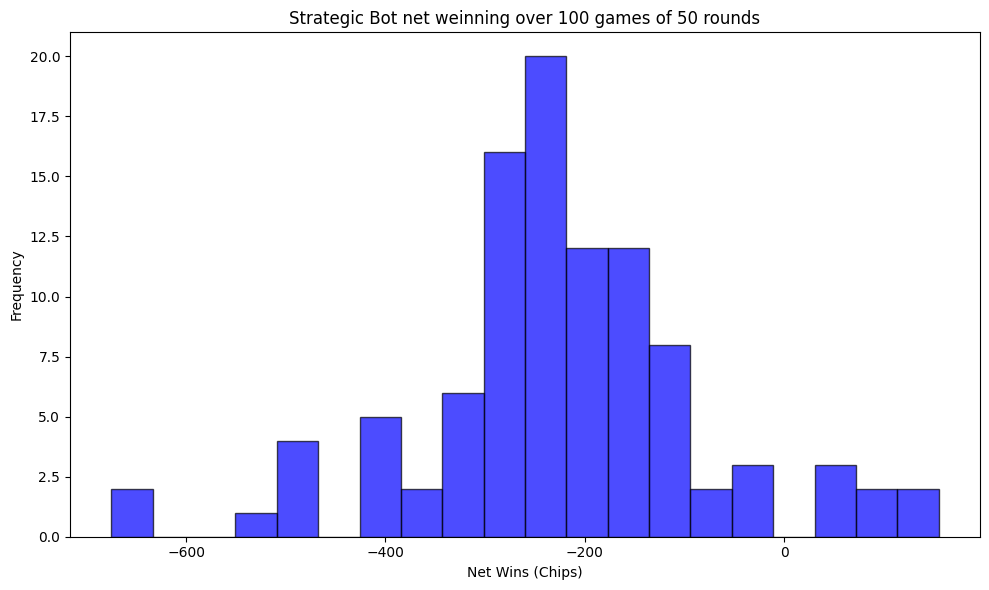

In [27]:
import numpy as np
from matplotlib import pyplot as plt


# 100 Games of 50 rounds in each game
starting_chips= 1000
games=100    
rounds=50

winnings=[]    #List to store net wins for each game of Strategic Player

for game_number in range(games):    #Loop for 100 games
    players= [
        NewStrategyComputer("Strategy Bot"),
        Computer("Bot1"),
        Computer("Bot2"),
        Computer("Bot3"),
    ]    #Define same player over the course of 100 games

    game= Blackjack(players, verbose=False)    #Create Blackjack game object
    strategy_player= players[0]    #Separate strategic player for tracking
    starting_chips= strategy_player.chips    #Strategic players' chips before the game strarts

    for round_number in range(1, rounds+1):    #Loops for 50 round in each game
        if strategy_player.chips <=0:
            break    #If strategic player runs out of chips, the game stops immediately.
        game.play_round()
    
    winnings.append(strategy_player.chips-starting_chips)    #Append the net winning of the each game (out of 100)

winnings= np.array(winnings)    #Convert to numpy array for easier operations
average_wins= np.mean(winnings)    #Average Wins/Loose per game
average_per_round= average_wins/rounds    #Average Chips Won/Loss per round
std_wins= np.std(winnings, ddof=1)    #Standard Deviation of Net chips won
prob_net_win= np.mean(winnings > 0)    #Proportion where final chips > starting chips
prob_net_loss= np.mean(winnings < 0)    #Proportion where final chips < starting chips
prob_break_even= np.mean(winnings == 0)    #Proportion where final chips = starting chips

# Print the above calculated results
print(f"Results over {games} games of {rounds} rounds:")
print(f"\nAverage winnings per game: {average_wins:+.2f}")
print(f"Average wins per round: {average_per_round:+.2f}")
print(f"Standard Deviation: {std_wins:+.2f}")
print(f"Probability of net win: {prob_net_win:.1%}")
print(f"Probability of net Loss: {prob_net_loss:.1%}")
print(f"Probability of break even: {prob_break_even:.1%}")

#Histogram
plt.figure(figsize=(10,6))
plt.hist(x=winnings, bins=20, edgecolor='black', color='blue', alpha=0.7)
plt.title(f"Strategic Bot net weinning over {games} games of {rounds} rounds")
plt.xlabel("Net Wins (Chips)")
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

The gievn histogram show the Net winnings of the Strategic bot over 100 games of 50 rounds each. The bot had a net loss in `94%` of the game with most of the loss being around **200 to 300** chips. Only `6%` of the game resulted in a net profit. The heavy tail of the left shows that the worst rounds of games caused loss of **450+** chips. 
Overall, the hsitogram shows that it is almost certain for a player following this strategy, the bot followed, to loose in a casino game of Blackjack.

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

In [28]:
class NewStrategyComputer(Player):
    def __init__(self, name, threshold=0):    #Provided option for passing threshold argument with default value being 0.
        super().__init__(name)
        self.running_count=0
        self.threshold= threshold

    def place_bet(self):
        if self.running_count > 2:
            bet = min(30, self.chips)
        elif self.running_count < -2:
            bet = min(5, self.chips)
        else:
            bet = min(10, self.chips)
        self.hand.bet = bet
        self.chips -= bet

    def update_count(self, card):
        if isinstance(card.value, int):
            if 2 <= card.value <=6:
                self.running_count+=1
            elif 7<= card.value <=9:
                self.running_count+=0
            else:
                self.running_count-= 1
        else:
            self.running_count-=1
        
    def decide(self):
        move= "hit" if self.running_count < self.threshold else "stand"
        return move
    
    def win(self):
        self.chips+=self.hand.bet * 2

    def push(self):
        self.chips+=self.hand.bet

Results over 100 games of 50 rounds:

Threshold      Avg Winnings    Avg/Round    Std Dev   P(Win)  P(Loss)
--------------------------------------------------------------------
-4                  -177.45        -3.55     127.09     9.0%    91.0%
-2                  -193.90        -3.88     146.09     7.0%    92.0%
0                   -204.40        -4.09     140.91     9.0%    91.0%
2                   -298.70        -5.97     143.51     4.0%    95.0%
4                   -364.55        -7.29     156.74     2.0%    98.0%

Optimal threshold: -4 (Avg winnings: -177.45)


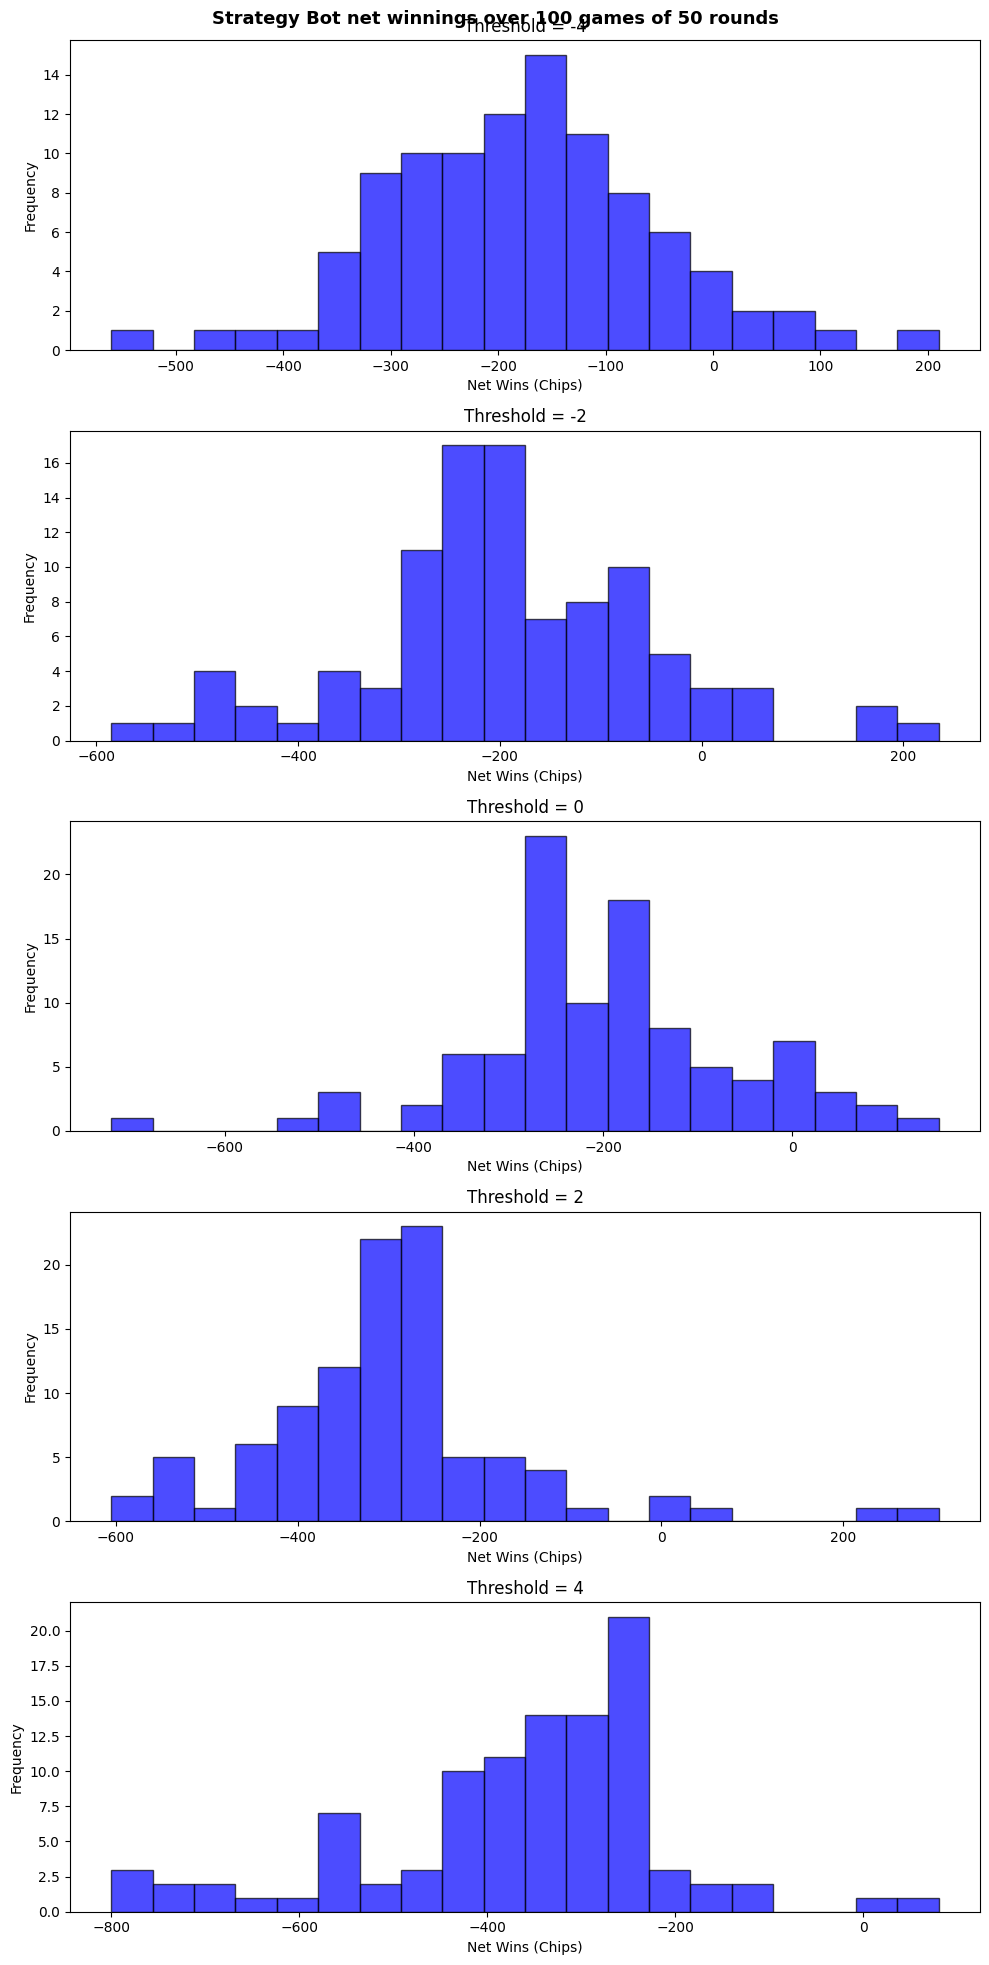

In [29]:
STARTING_CHIPS = 1000
GAMES = 100
ROUNDS = 50
THRESHOLDS = [-4, -2, 0, 2, 4]    #Initialize some random threshold values

results = {}    #For storing winning array for each threshold

#Loops over every threshold values
for threshold in THRESHOLDS:
    winnings = []    #For every threshold, winnings list is reset

    for game_number in range(GAMES):
        players = [
            NewStrategyComputer("Strategy Bot", threshold=threshold),    #Pass the current threshold
            Computer("Bot1"),
            Computer("Bot2"),
            Computer("Bot3"),
        ]

        game = Blackjack(players, verbose=False)
        strategy_player = players[0]
        starting_chips = strategy_player.chips

        for round_number in range(1, ROUNDS + 1):
            if strategy_player.chips <= 0:
                break
            game.play_round()

        winnings.append(strategy_player.chips - starting_chips)

    results[threshold] = np.array(winnings)

# --- Stats ---
print(f"Results over {GAMES} games of {ROUNDS} rounds:\n")
print(f"{'Threshold':<12} {'Avg Winnings':>14} {'Avg/Round':>12} {'Std Dev':>10} {'P(Win)':>8} {'P(Loss)':>8}")
print("-" * 68)

#Calculate and print one stats row per threshold
for threshold, winnings in results.items():
    average_wins     = np.mean(winnings)    #Mean net winning across all game
    average_per_round= average_wins / ROUNDS    #Average chips gained/lost per round
    std_wins         = np.std(winnings, ddof=1)    #Standard deviation of the outcome
    prob_net_win     = np.mean(winnings > 0)    #Proportion where final chips > starting chips
    prob_net_loss    = np.mean(winnings < 0)  #Proportion where final chips < starting chips
    print(f"{threshold:<12} {average_wins:>+14.2f} {average_per_round:>+12.2f} {std_wins:>10.2f} {prob_net_win:>8.1%} {prob_net_loss:>8.1%}")

best_threshold = max(results, key=lambda t: np.mean(results[t]))
print(f"\nOptimal threshold: {best_threshold} (Avg winnings: {np.mean(results[best_threshold]):+.2f})")

# --- Histograms ---
#One subplot per threshold, with subplots stacked vertically for easier comparision
fig, axes = plt.subplots(len(THRESHOLDS), 1, figsize=(10, 4 * len(THRESHOLDS)))

for ax, (threshold, winnings) in zip(axes, results.items()):
    ax.hist(winnings, bins=20, edgecolor='black', color='blue', alpha=0.7)
    ax.set_title(f'Threshold = {threshold}')
    ax.set_xlabel('Net Wins (Chips)')
    ax.set_ylabel('Frequency')

plt.suptitle(f'Strategy Bot net winnings over {GAMES} games of {ROUNDS} rounds',fontsize=13, fontweight='bold')
plt.tight_layout()    #Prevents overlapping of plots and title
plt.show()

Although the variation in threshold didn't help turn the tables, we can see changes in histogram as the threshold changes. We can see a trend in the distribution as the threshold value changes. Among the tested threshold, we can say that the threshold of `-4` has the highest win probability i.e. `12%` and lowest average loss per game i.e. 156.2

`NOTE:` AI was used for displaying the statistical result in proper tabular format.

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

The method I found is **Optimla Basic Strategy** where the decisions of a bot/player will be based on both player's hand value and the dealer's visible upcard: a standard Blackjack strategy followed to make decisions.

In [30]:
class BasicStrategyComputer(Player):
    def __init__(self, name):
        super().__init__(name)    #Inherits & Initializes the methods and attributes from Player

    
    #Places a fix bet of 10 chips per round (or all remaining chips if under 10 chips).
    def place_bet(self):
        bet = min(10, self.chips)    #bet is minimum among current chip and 10
        self.hand.bet = bet    # Update bet
        self.chips -= bet    #Update chips after bet

    
    #Identify soft hand (i.e. hand contains Ace counted as 11, without busting)
    def _is_soft_hand(self):
        values = [card.value for card in self.hand.card_in_hand]
        if "A" not in values:
            return False    #Return false if no Ace in hand
        
        #Sum of all cards in hands except for aces.
        total_without_aces= sum(
            v if isinstance(v, int) else 10
            for v in values if v!= "A"
        )    #Loops through values, selects cards that are not Ace, then adds all other card values
        return total_without_aces+11<=21    #If hand value is <= 21 after Ace being counted as 11, returns True: soft hand
    
    #Decides hit/stand observing both dealer card and whether hand is soft or not
    def decide(self, dealer_upcard= None):
        hand_value= self.hand.calculate_value()
        is_soft= self._is_soft_hand()

        #Dealer's Visible card Value
        if dealer_upcard is not None:
            if isinstance(dealer_upcard.value, int): #If the card is numeric shows corresponding card value
                dealer_val= dealer_upcard.value
            elif dealer_upcard.value in ["J", "Q", "K"]:    #IF it is face card excet for Ace: 10
                dealer_val= 10
            else:    #If the card is Ace: 11
                dealer_val= 11
        else:    #Assume card value as 10 if not shown
            dealer_val= 10
        
        
        #Soft Hand Strategy
        if is_soft:
            if hand_value>=19:    #If hand is soft and value >=19 stand
                return "stand"
            if hand_value==18:    #If hand value is equal to 18
                return "stand" if dealer_val in range(2,9) else "hit"    #Hit if face card or Ace, else stand
            return "hit"
        
        #Hard Hand Strategy
        if hand_value >=17:
            return "stand"    #If current hand value > 17 stand.
        if hand_value>=13 and dealer_val in range(2,7):
            return "stand"    #If current hand value in 13-16 and dealer's visible card is in 2-6(7 not included), stand
        if hand_value==12 and dealer_val in range(4,7):
            return "stand"    #If hand value is equal to 12 and dealer hand is in in 4 to 6 (7 not included), stand
        return "hit"    #If none of the above conditions satisfy, hit
    
    def win(self):    #Player gets double their bet on a win
        self.chips+=self.hand.bet * 2

    def push(self):    #Player gets bet amount back if push
        self.chips+=self.hand.bet

In [31]:
class Blackjack:
    def __init__(self, players, verbose= False):
        self.deck= Deck()
        self.players= players
        self.dealer= Dealer()
        self.verbose= verbose    #Controls print statements
    
    def deal_initial(self):
        for player in self.players:
            player.hand= Hand()
            player.place_bet()
        
        self.dealer.hand= Hand()

        for _ in range(2):
            for player in self.players:
                card= self.deck.draw()
                player.hand.add_card(card)
                if isinstance(player, NewStrategyComputer):
                    player.update_count(card)
            dealer_card= self.deck.draw()
            self.dealer.hand.add_card(dealer_card)
            for player in self.players:
                if isinstance(player, NewStrategyComputer):
                    player.update_count(dealer_card)

        if self.verbose:    #Only print initial hands if verbose was passed as True
            print("\nInitial Hands")
            print(f"Dealer shows: {self.dealer.hand.card_in_hand[0]} | [Hidden]")
            for player in self.players:
                print(f"{player.name}: {player.hand}")
            print()
        
    def player_turn(self):
        dealer_upcard= self.dealer.hand.card_in_hand[0]    #Extracting dealers visible/1st card to use in the strategy
        for player in self.players:
            if self.verbose:
                print(f"\n\n{player.name}'s Turn")
            
            #Loops until the player hasn't busted
            while not player.hand.is_bust():
                if self.verbose:
                    print(player.hand)


                if isinstance(player, BasicStrategyComputer):    #IF the player is an object of BasicStrategyComputer
                    move= player.decide(dealer_upcard=dealer_upcard)    #Decision from strategy
                else:    #Decision else (When the player doesn't follow the wanted strategy)
                    move= player.decide()


                if move == "stand":    #Stop the  loop if move is stand
                    break
                    
                
                #Player chose to hit- Draw card and add it to their hand
                card= self.deck.draw()
                if self.verbose:
                    print(f"{player.name} Drew: {card}")
                player.hand.add_card(card)
                if isinstance(player, NewStrategyComputer):
                    player.update_count(card)    #Update count with each new card drawn during turn

            
            #Notify if the player went over 21
            if player.hand.is_bust():
                if self.verbose:
                    print(f"{player.name}'s Bust with {player.hand.calculate_value()}.")
                continue    #Moves to next player.
            
    def dealer_turn(self):
        if self.verbose:
            print(f"\n Dealer Hand: {self.dealer.hand}")
        while self.dealer.decide()=='hit':
            card= self.deck.draw()
            if self.verbose:
                print(f"Dealer Draws: ", card)
            self.dealer.hand.add_card(card)
    
    
    def settle_bets(self):
        dealer_hand_value= self.dealer.hand.calculate_value()
        if self.verbose:
            print(f"\nDealer's final Hand: {dealer_hand_value}")

        for player in self.players:
            player_hand_value= player.hand.calculate_value()
            if self.verbose:
                print(f"\n {player.name}: {player.hand}")
            if player.hand.is_bust():
                if self.verbose:
                    print(f"{player.name} Lost (Bust)")

            elif player.hand.is_blackjack() and not self.dealer.hand.is_blackjack():
                if self.verbose:
                    print(f"Blackjack! {player.name} wins!")
                player.chips+=int(player.hand.bet) * 2.5
            elif dealer_hand_value>21 or player_hand_value>dealer_hand_value:
                if self.verbose:
                    print(f"{player.name} Won.")
                player.win()
            
            elif player_hand_value == dealer_hand_value:
                if self.verbose:
                    print(f"Push for {player.name}")
                player.push()
            
            else:
                if self.verbose:
                    print(f"{player.name} Lost!")
            if self.verbose:
                print("Chips:", player.chips)

    def play_round(self):
        self.players= [player for player in self.players if player.chips > 0]
        if not self.players:
            if self.verbose:
                print("No players remaining.")
            return
        
        self.deal_initial()
        self.player_turn()
        self.dealer_turn()
        self.settle_bets()

`NOTE:` AI was used for the efficient plotting for the exercise


Strategy                    Avg    Per Round        Std   P(Win)  P(Loss)
------------------------------------------------------------------------
Basic Strategy           -22.80        -0.46      65.99    36.0%    62.0%
Hi-Lo (t=-4)            -176.07        -3.52     115.37     5.0%    95.0%
Computer                 -29.20        -0.58      64.75    31.0%    65.0%


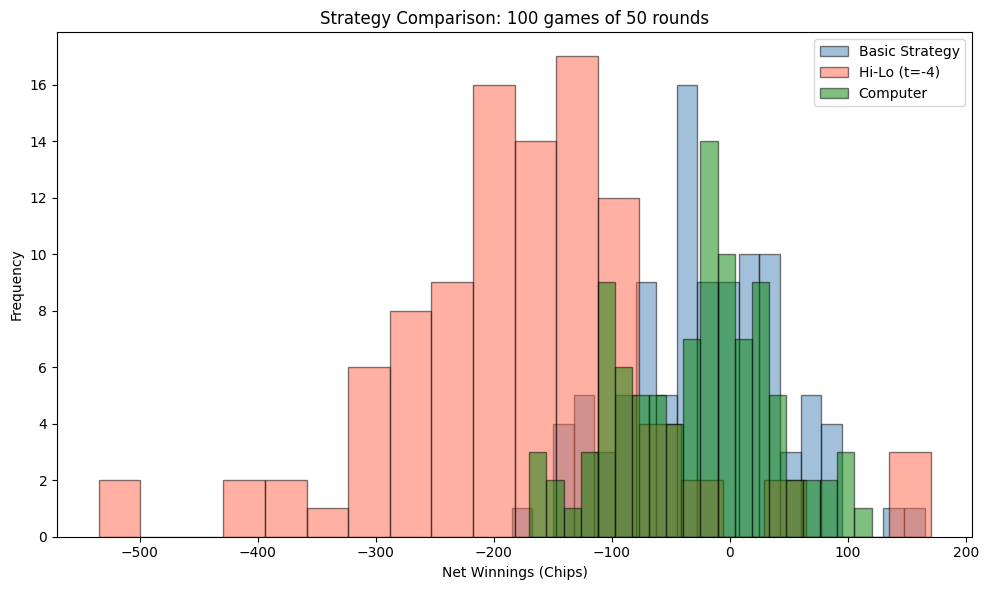

In [32]:
import numpy as np
import matplotlib.pyplot as plt

STARTING_CHIPS = 1000
GAMES = 100
ROUNDS = 50

#Strategy: Each entry maps a strategy name to a lambda function
#Lambda function creates a fresh player instance for every game
strategies = {
    "Basic Strategy" : lambda: BasicStrategyComputer("Basic Strategy"),
    "Hi-Lo (t=-4)"   : lambda: NewStrategyComputer("Hi-Lo", threshold=-4),
    "Computer"      : lambda: Computer("Computer"),
}

results = {}    #Stores winnings array for each strategy

for strategy_name, strategy_fn in strategies.items():
    winnings = []    #net winnings list for each strategy

    for _ in range(GAMES):
        #Fresh players each game to fully reset chips and state
        players = [
            strategy_fn(),
            Computer("Bot1"),
            Computer("Bot2"),
            Computer("Bot3"),
        ]
        game = Blackjack(players, verbose=False)
        strategy_player = players[0]    #Isolate strategy player for observation

        for _ in range(ROUNDS):
            if strategy_player.chips <= 0:
                break    #Stop the game if strategic player/bot runs out of chips before the game ends
            game.play_round()

        winnings.append(strategy_player.chips - STARTING_CHIPS)    #Store net gain/loss for current game

    results[strategy_name] = np.array(winnings)    #Store all game results for current strategy (loop)

# --- Stats ---
#Print formatted comparision table- one row per strategy
print(f"\n{'Strategy':<20} {'Avg':>10} {'Per Round':>12} {'Std':>10} {'P(Win)':>8} {'P(Loss)':>8}")
print("-" * 72)
for name, winnings in results.items():
    print(f"{name:<20} {np.mean(winnings):>+10.2f} {np.mean(winnings)/ROUNDS:>+12.2f} "
          f"{np.std(winnings, ddof=1):>10.2f} {np.mean(winnings>0):>8.1%} {np.mean(winnings<0):>8.1%}")

# --- Overlapping Histograms ---
#Each strategy is plotted with a distinct color and transparency under same axes
colors = ["steelblue", "tomato", "green"]    #Setting colors
plt.figure(figsize=(10, 6))    #Creates a canvas
for (name, winnings), color in zip(results.items(), colors):    #Plots a histogram for each strategy using one of the above color in sequential order
    plt.hist(winnings, bins=20, alpha=0.5, color=color, edgecolor='black', label=name)

plt.title(f'Strategy Comparison: {GAMES} games of {ROUNDS} rounds')    #Title the plot
plt.xlabel('Net Winnings (Chips)')    # Labeling x axis
plt.ylabel('Frequency')    #Labeling y-axis
plt.legend()    #Shows what color represents which strategy
plt.tight_layout()    #Prevents collapse of title and plots
plt.show()

The performace of the 'computer strategy' (hit <17 else stand) and the basic strategy we just implemented seems to outperform the Hi-Lo strategy that the StrategicComputer used. However, the overall probability of loosing the game is still high for both 'Basic Strategy' and 'Computer Strategy' with no gurantee of long term profit in the game, which explains the true results of the Casino games.